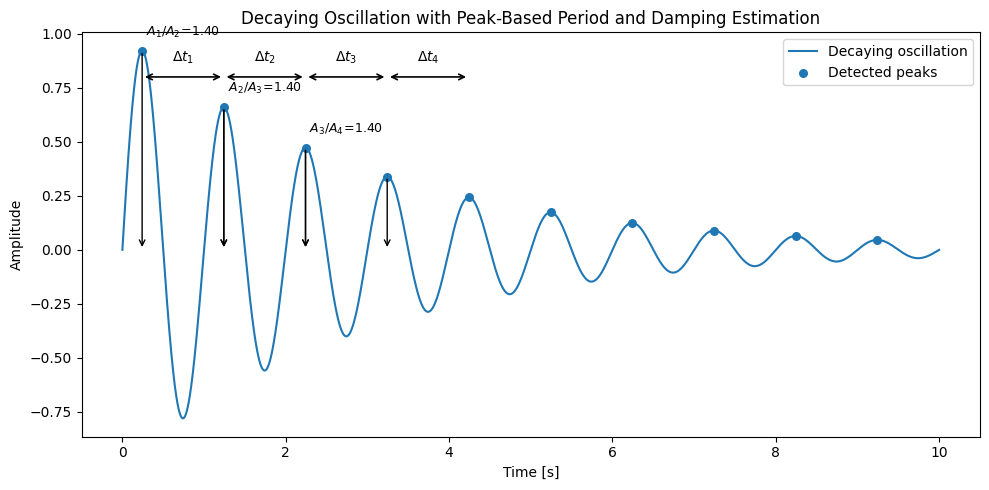

In [1]:
# Generate a decaying oscillatory signal and visualize how to estimate
# (1) the period as the average distance between consecutive peaks, and
# (2) the damping factor as the average of (current peak amplitude / next peak amplitude).
#
# Notes per user request:
# - Deterministic (no noise).
# - One plot (no subplots).
# - Matplotlib only (no seaborn), and not specifying any colors.

import numpy as np
import matplotlib.pyplot as plt

# --- Generate a deterministic, decaying sinusoid ---
A = 1.0          # initial amplitude
f = 1.0          # frequency in Hz
tau = 3.0        # decay constant in seconds
phi = 0.0        # phase
t_end = 10.0
fs = 1000        # samples per second

t = np.linspace(0, t_end, int(fs*t_end), endpoint=False)
y = A * np.exp(-t / tau) * np.sin(2*np.pi*f*t + phi)

# --- Simple local-maximum peak detection (no SciPy dependency) ---
# Find indices where y[i-1] < y[i] >= y[i+1] and y[i] > 0 (positive peaks only)
candidates = (y[1:-1] > y[:-2]) & (y[1:-1] >= y[2:])
peak_idx_all = np.where(candidates)[0] + 1
# Keep only positive peaks (for amplitude ratio interpretation)
peak_idx = peak_idx_all[y[peak_idx_all] > 0]

t_peaks = t[peak_idx]
a_peaks = y[peak_idx]

# We need at least 3-4 peaks to annotate effectively
# If too few peaks are found (unlikely here), shorten t_end or parameters.
if len(peak_idx) < 3:
    raise RuntimeError("Not enough peaks detected; adjust signal parameters.")

# --- Compute metrics ---
periods = np.diff(t_peaks)
avg_period = periods.mean()

amp_ratios = a_peaks[:-1] / a_peaks[1:]
avg_damping_factor = amp_ratios.mean()

# --- Plot ---
plt.figure(figsize=(10, 5))
plt.plot(t, y, linewidth=1.5, label="Decaying oscillation")
plt.scatter(t_peaks, a_peaks, s=30, zorder=3, label="Detected peaks")

# Draw arrows along the time axis between the first few peak pairs to depict Δt (period estimates)
num_pairs_to_annotate = min(4, len(t_peaks)-1)
y_arrow_level = 0.8 * A  # place period arrows near the top region

for i in range(num_pairs_to_annotate):
    t0 = t_peaks[i]
    t1 = t_peaks[i+1]
    # Horizontal double-arrow to show Δt between two consecutive peaks
    plt.annotate(
        "",
        xy=(t1, y_arrow_level),
        xytext=(t0, y_arrow_level),
        arrowprops=dict(arrowstyle="<->", lw=1.2),
        annotation_clip=False
    )
    # Label for the pair's Δt
    mid_t = 0.5 * (t0 + t1)
    plt.text(mid_t, y_arrow_level + 0.05*A, r"$\Delta t_{}$".format(i+1),
             ha="center", va="bottom")

# Draw amplitude ratio arrows (vertical markers) on the first few positive peaks
num_ratios_to_annotate = min(3, len(a_peaks)-1)
for i in range(num_ratios_to_annotate):
    t0 = t_peaks[i]
    t1 = t_peaks[i+1]
    a0 = a_peaks[i]
    a1 = a_peaks[i+1]
    # Vertical arrows on each of the two peaks to visualize the amplitudes compared
    plt.annotate("", xy=(t0, a0), xytext=(t0, 0), arrowprops=dict(arrowstyle="<-", lw=1.0))
    plt.annotate("", xy=(t1, a1), xytext=(t1, 0), arrowprops=dict(arrowstyle="<-", lw=1.0))
    # Ratio label placed midway in time, slightly above the smaller amplitude
    label_y = max(a0, a1) + 0.05*A
    plt.text(0.5*(t0+t1), label_y,
             r"$A_{%d}/A_{%d}\!=\!%.2f$" % (i+1, i+2, a0/a1),
             ha="center", va="bottom", fontsize=9)

# Summary text box
# summary = (
#     r"Estimated period  $T \approx \mathrm{mean}(\Delta t)$ = %.3f s" "\n"
#     r"Estimated damping factor  $\alpha \approx \mathrm{mean}(A_i/A_{i+1})$ = %.3f"
# ) % (avg_period, avg_damping_factor)

plt.title("Decaying Oscillation with Peak-Based Period and Damping Estimation")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.legend(loc="upper right")

# Place a text box
# plt.gcf().text(0.02, 0.95, summary, ha="left", va="top",
#                bbox=dict(boxstyle="round", alpha=0.2))


plt.tight_layout()

# Save the figure for download
plt.savefig('decay_period.png', dpi=200, bbox_inches="tight")
